In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.stats import wasserstein_distance

In [43]:
fichiers = [
    ("WV1_Data.csv", "V66"),
    ("WV7_Data.csv", "Q48"),
]

opinion_list = []
for fichier, colonne in fichiers:
    sep = "," if "WV7" in fichier else ";"
    df = pd.read_csv(fichier, sep=sep, low_memory=False, on_bad_lines='skip')
    df.columns = df.columns.str.strip()
    opinions = pd.to_numeric(df[colonne], errors='coerce').dropna()
    opinion_list.append(opinions)


In [44]:
np.random.seed(42)
taille = 500
opinion_list = [
    np.random.choice(
        (opinions - opinions.min()) / (opinions.max() - opinions.min()),
        size=taille,
        replace=False
    ) for opinions in opinion_list
]

initial_opinions = opinion_list[0]
target_opinions = opinion_list[1]


In [45]:
T = 10
n_normals = taille
n_radicals = 3
bins = 100
bin_edges = np.linspace(0, 1, bins + 1)
beta = 10
alpha = 0.1
epsilon = 0.1
radical_weight = 10

In [46]:
def phi(diff, beta):
    return 1 / (1 + np.exp(beta * (np.abs(diff) - epsilon)))

def simulate_continuous_model(radicals, initial_opinions, n_radicals, T):
    radicals = np.array(radicals).reshape((T, n_radicals))
    opinions = np.copy(initial_opinions)
    historique = [opinions.copy()]
    for t in range(T):
        rads = radicals[t]
        total_opinions = np.concatenate([opinions, rads])
        updated_opinions = np.copy(opinions)
        for i in range(len(opinions)):
            xi = opinions[i]
            xj = total_opinions
            influence_weights = phi(xi - xj, beta)
            influence_weights[i] = 0
            influence_weights[-n_radicals:] *= radical_weight
            sum_weights = np.sum(influence_weights)
            if sum_weights > 0:
                influence = np.sum(influence_weights * (xj - xi)) / sum_weights
                updated_opinions[i] = xi + alpha * influence
        opinions = np.clip(updated_opinions, 0, 1)
        historique.append(opinions.copy())
    return opinions, np.array(historique)

def cost_function(radicals, n_normals, n_radicals, T, initial_opinions, target_opinions):
    final_opinions, _ = simulate_continuous_model(radicals, initial_opinions, n_radicals, T)
    return wasserstein_distance(final_opinions, target_opinions)

In [48]:
bounds = [(0, 1)] * (T * n_radicals)
result = differential_evolution(
    cost_function,
    bounds,
    maxiter=40,
    args=(n_normals, n_radicals, T, initial_opinions, target_opinions),
    disp=True
)
radicals = result.x.reshape((T, n_radicals))
final_opinions, historique = simulate_continuous_model(result.x, initial_opinions, n_radicals, T)

differential_evolution step 1: f(x)= 0.09480029021938403
Polishing solution with 'L-BFGS-B'


In [49]:
print("Radicaux optimaux (u) :")
print(radicals)

Radicaux optimaux (u) :
[[0.14533386 1.         0.14563573]
 [0.99976974 0.99971893 0.14889435]
 [0.99437552 0.15976747 0.15963066]
 [0.99219946 0.99207202 0.99201617]
 [0.98829682 0.98829282 0.98811604]
 [0.98219605 0.17439259 0.1744447 ]
 [0.18073826 0.97885812 0.97894664]
 [0.97362602 0.18987143 0.18936987]
 [0.97191181 0.97181405 0.97194908]
 [0.96560646 0.20189563 0.20261096]]


In [50]:
time_steps = np.arange(T+1)

def afficher_historique():
    for agent in range(n_normals):
        plt.plot(time_steps, historique[:, agent], alpha=0.8, linewidth=0.8)
    for i in range(n_radicals):
        radical_opinions_over_time = radicals[:, i]
        plt.plot(
            time_steps[:-1],
            radical_opinions_over_time,
            marker='o',
            linestyle='-',
            color='blue',
            linewidth=2
        )
    plt.ylim(0, 1)
    plt.xlabel("Temps")
    plt.ylabel("Opinion")
    plt.title("Évolution des opinions et des radicaux")
    plt.grid(True)
    plt.legend()
    plt.show()

C:\Users\maste\AppData\Local\Temp\ipykernel_528492\1645024589.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


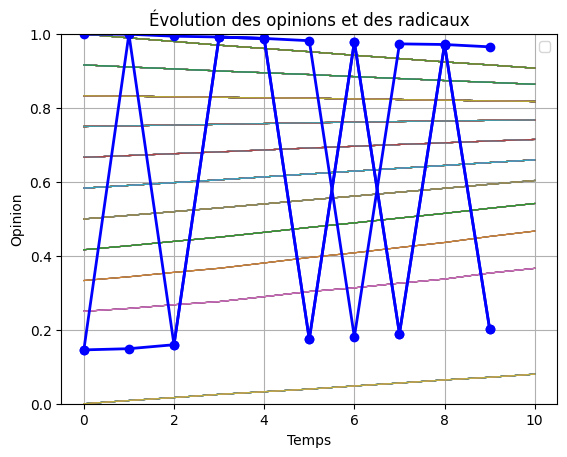

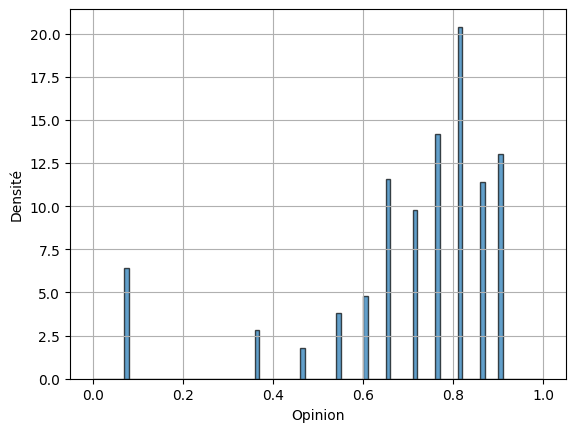

In [56]:
afficher_historique()
plt.hist(historique[-1], bins=bin_edges, alpha=0.7, edgecolor='black', density=True)
plt.xlabel("Opinion")
plt.ylabel("Densité")
plt.grid(True)
plt.show()
